# Tech Challenge: Diagnóstico Preditivo de Diabetes
**Autor:** Marcius Lucas Fernandes

## 1. Introdução e Objetivo
Este projeto consiste no desenvolvimento de um modelo de Machine Learning para auxílio ao diagnóstico de diabetes, utilizando o dataset Pima Indians Diabetes. O objetivo central é maximizar a segurança do paciente, priorizando a identificação de casos positivos (Recall) para evitar que doentes fiquem sem tratamento.

## 2. Configuração do Ambiente e Carga de Dados
Nesta etapa, importamos a biblioteca Pandas para manipulação de dados e carregamos o dataset para o ambiente de desenvolvimento.

In [1]:
import pandas as pd

# 1. Instanciamento e leitura do arquivo
df = pd.read_csv("../../datasets/dataset-diabetes.csv")

# 2. Exibição das 5 primeiras linhas para inspecionar a estrutura
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 3. Análise Exploratória Inicial (EDA)
Geramos as estatísticas descritivas básicas para entender a distribuição inicial dos dados e buscar possíveis anomalias, como valores mínimos zerados em exames onde isso é biologicamente impossível.

In [2]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Verificamos a volumetria do nosso conjunto de dados e os tipos de variáveis disponíveis.

In [3]:
# 1. Verifica o tamanho da tabela (linhas, colunas)
print("Formato da tabela:", df.shape)

# 2. Verifica os tipos de dados e se há valores nulos explícitos
print("\nInformações das colunas:")
df.info()

Formato da tabela: (768, 9)

Informações das colunas:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### 4. Limpeza e Tratamento de Dados
Removemos possíveis pacientes duplicados. Além disso, identificamos a "Armadilha dos Zeros": exames como Glicose e Pressão Sanguínea não podem ter valor 0. Substituímos esses zeros por `NaN` (nulo) para que a máquina não aprenda padrões incorretos.

In [4]:
import numpy as np

# 1. Remoção de pacientes duplicados no sistema
df = df.drop_duplicates()

# 2. Tratamento da "Armadilha dos Zeros" (valores biologicamente impossíveis)
colunas_erro = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[colunas_erro] = df[colunas_erro].replace(0, np.nan)

# 3. Inspeção pós-tratamento para mapear os dados faltantes reais
print("Dados faltantes (NaN) reais mapeados após a limpeza:")
print(df.isnull().sum())

Dados faltantes (NaN) reais mapeados após a limpeza:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Executamos uma nova validação estatística para confirmar que os zeros anômalos foram corretamente removidos do cálculo de mínimos.

In [5]:
# Gerando a estatística descritiva para procurar anomalias no valor "min"
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 5. Divisão dos Dados (Treino e Teste)
Para garantir que o modelo seja avaliado de forma justa, isolamos 20% dos dados como Teste. Utilizamos a divisão estratificada (`stratify`) para garantir que a proporção de pacientes doentes e saudáveis seja a mesma em ambos os cofres.

In [6]:
from sklearn.model_selection import train_test_split

# 1. Separando os Exames (X) do Diagnóstico (y) da tabela que já está limpa
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 2. O Corte Estratificado (80% Treino / 20% Teste)
# O parâmetro 'stratify=y' é o que garante uma proporção igualitária.
# O 'random_state=42' garante que o corte seja exatamente o mesmo se precisarmos rodar o código de novo.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Verificando o tamanho dos pacotes após o corte
print(f"Base de Treino (X_train): {X_train.shape[0]} pacientes.")
print(f"Base de Teste (X_test): {X_test.shape[0]} pacientes.")

Base de Treino (X_train): 614 pacientes.
Base de Teste (X_test): 154 pacientes.


### 6. Análise de Correlação (Base de Treino)
Utilizamos um Mapa de Calor de Pearson para identificar quais variáveis têm maior influência matemática no diagnóstico positivo. A Glicose destacou-se como o preditor mais forte.

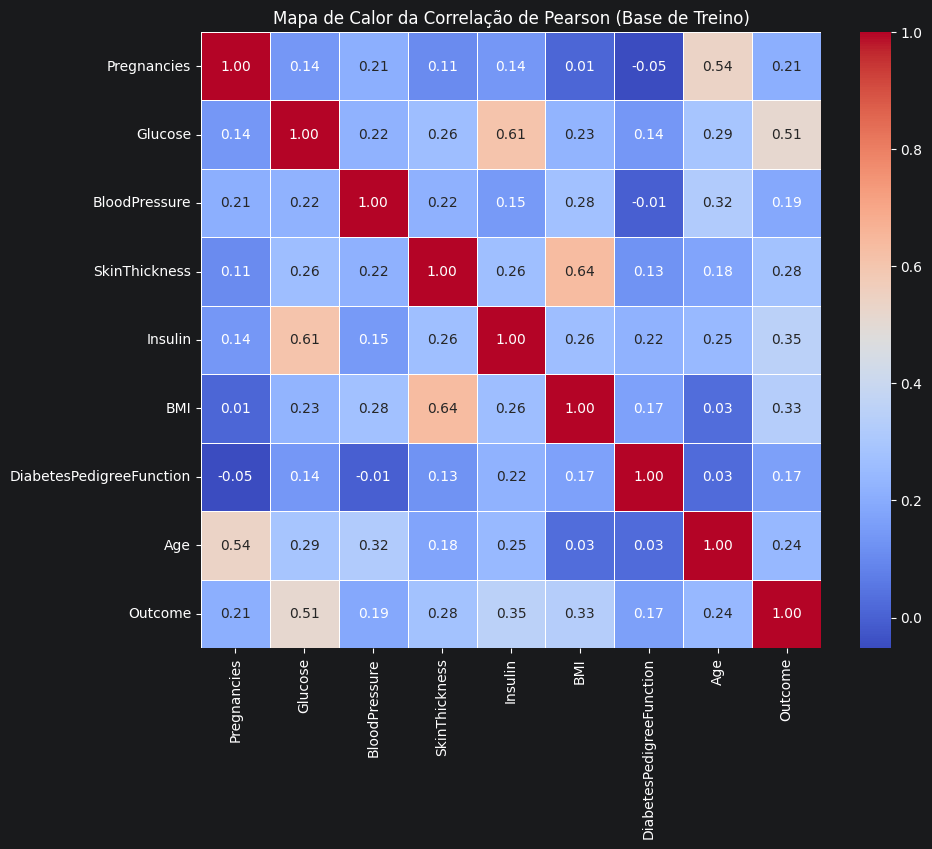

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Junção temporária (apenas na base de Treino) para evitar o vazamento de dados
dados_treino_eda = X_train.copy()
dados_treino_eda['Outcome'] = y_train

# 2. Cálculo da matriz de correlação de Pearson
matriz_correlacao = dados_treino_eda.corr()

# 3. Configuração e plotagem do Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor da Correlação de Pearson (Base de Treino)')
plt.show()

Visualizamos a distribuição da Glicose cruzada com o diagnóstico. O gráfico confirma a tendência de níveis mais altos de glicose em pacientes diagnosticados com diabetes.

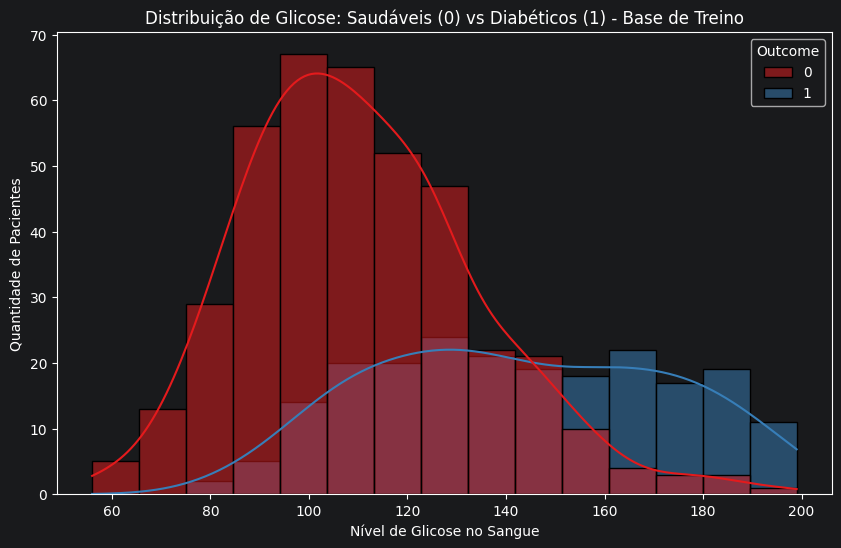

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuramos o tamanho do quadro
plt.figure(figsize=(10, 6))

# 2. Desenhamos o Histograma
# data: nossa tabela rascunho de treino
# x: o exame que estamos analisando (Glicose)
# hue: o carimbo mágico que separa as cores (Diagnóstico)
# kde=True: desenha uma linha suave por cima das torres para ajudar a ver o formato da "montanha"
# palette='Set1': usa cores fortes (vermelho e azul) para facilitar o contraste
sns.histplot(data=dados_treino_eda, x='Glucose', hue='Outcome', kde=True, palette='Set1')

# 3. Colocamos os textos descritivos
plt.title('Distribuição de Glicose: Saudáveis (0) vs Diabéticos (1) - Base de Treino')
plt.xlabel('Nível de Glicose no Sangue')
plt.ylabel('Quantidade de Pacientes')

# 4. Exibimos a imagem
plt.show()

### 7. Preenchimento de Dados Faltantes (Imputação)
Para lidar com os dados nulos gerados na limpeza, aplicamos a técnica de imputação pela Mediana. O cálculo foi feito apenas na base de Treino para evitar o vazamento de informações para o Teste.

In [9]:
from sklearn.impute import SimpleImputer
import pandas as pd

# 1. Criamos a ferramenta configurada para usar a Mediana
imputer = SimpleImputer(strategy='median')

# 2. TREINO: O comando 'fit_transform' faz duas coisas:
#    - 'fit': APRENDE qual é a mediana olhando APENAS para os pacientes de Treino.
#    - 'transform': APLICA essa mediana descoberta para tapar os buracos do próprio Treino.
X_train_preenchido = imputer.fit_transform(X_train)

# 3. TESTE: O comando 'transform' faz apenas UMA coisa:
#    - APLICA a mesma mediana que foi aprendida no passo anterior para tapar os buracos do Teste.
#    - Ele NÃO calcula uma mediana nova.
X_test_preenchido = imputer.transform(X_test)

# 4. Devolvemos o formato de tabela (DataFrame) com os nomes das colunas originais
X_train = pd.DataFrame(X_train_preenchido, columns=X_train.columns)
X_test = pd.DataFrame(X_test_preenchido, columns=X_test.columns)

# 5. Verificação visual
print("Dados faltantes no Treino após imputação:\n", X_train.isnull().sum())

Dados faltantes no Treino após imputação:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


### 8. Padronização de Escala
Para evitar que variáveis com números naturalmente altos (como Insulina) dominem os algoritmos, nivelamos todas as colunas para a mesma escala matemática usando o `StandardScaler`.

In [10]:
from sklearn.preprocessing import StandardScaler

# 1. Criamos a ferramenta de padronização
scaler = StandardScaler()

# 2. TREINO: A máquina aprende a escala do Treino e já aplica a modificação.
X_train_escalado = scaler.fit_transform(X_train)

# 3. TESTE: A máquina aplica a modificação no Teste usando a régua que acabou de aprender.
X_test_escalado = scaler.transform(X_test)

# 4. Devolvemos os dados para o formato de tabela (DataFrame) para não perder os nomes das colunas.
X_train = pd.DataFrame(X_train_escalado, columns=X_train.columns)
X_test = pd.DataFrame(X_test_escalado, columns=X_test.columns)

# 5. Verificação visual
print("Base de Treino nivelada (amostra):\n")
print(X_train.head())

Base de Treino nivelada (amostra):

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.851355 -1.056427      -0.826740      -1.918187 -1.203361 -0.769694   
1     0.356576  0.144399       0.477772      -0.229874 -1.470195 -0.417714   
2    -0.549372 -0.556083      -1.152868       1.233330 -0.555335  0.359576   
3    -0.851355  0.811525      -1.315932      -0.004766 -0.161437 -0.403048   
4    -1.153338 -0.889646      -0.663676       1.120776 -0.415565  1.782163   

   DiabetesPedigreeFunction       Age  
0                  0.310794 -0.792169  
1                 -0.116439  0.561034  
2                 -0.764862 -0.707594  
3                  0.262314 -0.369293  
4                 -0.337630 -0.961320  


### 9. Modelagem: Regressão Logística (Baseline)
Iniciamos a fase de machine learning com um algoritmo linear clássico para estabelecer nossa linha de base. Ele servirá como ponto de comparação para os modelos mais complexos.

In [11]:
from sklearn.linear_model import LogisticRegression

# 1. Instanciando o modelo (Criando a ferramenta)
# O parâmetro 'max_iter=1000' dá ao algoritmo tempo suficiente para encontrar a melhor linha divisória.
# O 'random_state=42' garante que nossos resultados sejam reprodutíveis.
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

# 2. O Treinamento (Ajustando a ferramenta aos dados da sala de aula)
modelo_lr.fit(X_train, y_train)

print("Modelo de Regressão Logística treinado com sucesso!")

Modelo de Regressão Logística treinado com sucesso!


Executamos a predição na base de Teste isolada para validar o aprendizado do modelo.

In [12]:
# 1. A Prova Final (A máquina tenta adivinhar o diagnóstico)
y_pred_lr = modelo_lr.predict(X_test)

# 2. Vamos espiar as 5 primeiras respostas da máquina lado a lado com a realidade
print("Respostas da Máquina: ", y_pred_lr[:5])
print("Gabarito Real (Médico):", y_test[:5].values)

Respostas da Máquina:  [1 0 0 0 0]
Gabarito Real (Médico): [0 0 0 1 0]


Calculamos as métricas de avaliação. O foco principal da nossa análise crítica será o Recall (capacidade de não deixar doentes passarem despercebidos).

In [13]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

# A máquina calcula a nota comparando o Gabarito Real (y_test) com as Respostas dela (y_pred_lr)
acuracia = accuracy_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print(f"Acurácia (Total de acertos gerais): {acuracia * 100:.2f}%")
print(f"Recall (Capacidade de encontrar doentes): {recall * 100:.2f}%")
print(f"F1-Score (Equilíbrio geral): {f1 * 100:.2f}%")

Acurácia (Total de acertos gerais): 70.78%
Recall (Capacidade de encontrar doentes): 50.00%
F1-Score (Equilíbrio geral): 54.55%


### 10. Modelagem: Árvore de Decisão
Como o diagnóstico geralmente depende de uma combinação condicional de fatores, testamos uma Árvore de Decisão com parâmetros de fábrica.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

# 1. Instanciando o modelo (Criando a Árvore)
modelo_dt = DecisionTreeClassifier(random_state=42)

# 2. Treinamento (Ajustando aos dados de treino)
modelo_dt.fit(X_train, y_train)

# 3. A Prova Final (Máquina adivinha o Teste)
y_pred_dt = modelo_dt.predict(X_test)

# 4. Calculando as Notas
acuracia_dt = accuracy_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("--- Resultados: Árvore de Decisão ---")
print(f"Acurácia (Total de acertos): {acuracia_dt * 100:.2f}%")
print(f"Recall (Encontrar doentes): {recall_dt * 100:.2f}%")
print(f"F1-Score (Equilíbrio geral): {f1_dt * 100:.2f}%")

--- Resultados: Árvore de Decisão ---
Acurácia (Total de acertos): 68.18%
Recall (Encontrar doentes): 48.15%
F1-Score (Equilíbrio geral): 51.49%


Extraímos a "Feature Importance" para auditar o raciocínio da árvore. Validamos que a Glicose foi novamente confirmada como a raiz das decisões do modelo.

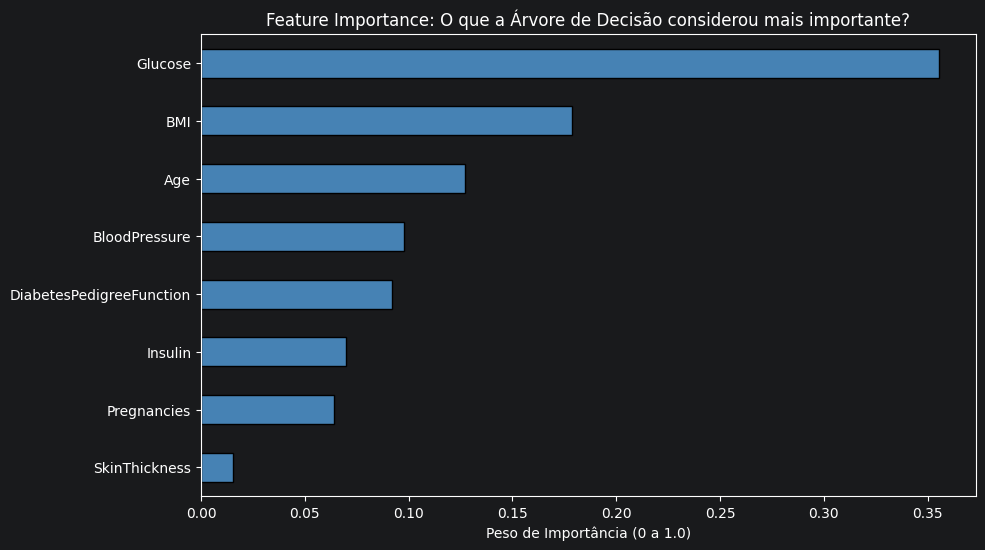

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraindo os pesos matemáticos que a própria máquina calculou
pesos = pd.Series(modelo_dt.feature_importances_, index=X_train.columns)
pesos = pesos.sort_values(ascending=True) # Ordenando do menor para o maior

# 2. Desenhando o gráfico
plt.figure(figsize=(10, 6))
pesos.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance: O que a Árvore de Decisão considerou mais importante?')
plt.xlabel('Peso de Importância (0 a 1.0)')
plt.show()

#### 10.1 Ajuste de Hiperparâmetros (max_depth)
A árvore padrão sofreu de *overfitting*, falhando na generalização. Limitamos a profundidade (`max_depth=4`) para cortar galhos excessivos e forçar a máquina a focar apenas em padrões robustos.

In [16]:
# 1. Instanciando o modelo ajustado (O código que você construiu)
modelo_dt_ajustado = DecisionTreeClassifier(random_state=42, max_depth=4)

# 2. Treinamento (Ajustando aos dados de treino)
modelo_dt_ajustado.fit(X_train, y_train)

# 3. A Prova Final (Máquina adivinha o Teste)
y_pred_dt_ajustado = modelo_dt_ajustado.predict(X_test)

# 4. Calculando as novas Notas
acuracia_ajustada = accuracy_score(y_test, y_pred_dt_ajustado)
recall_ajustado = recall_score(y_test, y_pred_dt_ajustado)
f1_ajustado = f1_score(y_test, y_pred_dt_ajustado)

print("--- Resultados: Árvore de Decisão AJUSTADA (max_depth=4) ---")
print(f"Acurácia (Total de acertos): {acuracia_ajustada * 100:.2f}%")
print(f"Recall (Encontrar doentes): {recall_ajustado * 100:.2f}%")
print(f"F1-Score (Equilíbrio geral): {f1_ajustado * 100:.2f}%")

--- Resultados: Árvore de Decisão AJUSTADA (max_depth=4) ---
Acurácia (Total de acertos): 78.57%
Recall (Encontrar doentes): 68.52%
F1-Score (Equilíbrio geral): 69.16%


### 11. Modelagem: Random Forest (Floresta Aleatória)
Buscando ainda mais estabilidade, implementamos o *Random Forest*. Para mitigar o desbalanceamento natural entre pacientes saudáveis e doentes, ativamos o peso matemático `class_weight='balanced'`, penalizando os erros nos diagnósticos da minoria (os diabéticos).

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

# 1. Instanciando o modelo (Com a instrução de focar nos doentes)
modelo_rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Treinamento (A máquina estuda a base de dados)
modelo_rf.fit(X_train, y_train)

# 3. A Prova Final (A máquina adivinha os diagnósticos do Teste)
y_pred_rf = modelo_rf.predict(X_test)

# 4. Calculando o Boletim de Notas
acuracia_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("--- Resultados: Random Forest (Balanceado) ---")
print(f"Acurácia (Total de acertos): {acuracia_rf * 100:.2f}%")
print(f"Recall (Encontrar doentes): {recall_rf * 100:.2f}%")
print(f"F1-Score (Equilíbrio geral): {f1_rf * 100:.2f}%")

--- Resultados: Random Forest (Balanceado) ---
Acurácia (Total de acertos): 74.68%
Recall (Encontrar doentes): 57.41%
F1-Score (Equilíbrio geral): 61.39%


### 12. Decisão Técnica Final e Conclusão (Ajuste de Limiar)
**Justificativa Técnica e Ética:** Na medicina preventiva, o erro mais oneroso é o Falso Negativo. O limiar padrão de 50% de confiança da máquina provou-se insuficiente em segurança.

Realizamos uma intervenção direta no limiar de decisão (*Threshold*), reduzindo-o para **30%**. O objetivo foi aumentar a sensibilidade do sistema, assumindo conscientemente uma maior taxa de Falsos Positivos (exames extras de triagem) em prol de um ganho expressivo na captura de doentes reais.

O modelo final atingiu o objetivo proposto, aproximando-se de 80% de Recall e entregando um sistema de apoio diagnóstico voltado para a segurança do paciente.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

# 1. Recriando e treinando o modelo original (com todas as colunas)
modelo_rf_final = RandomForestClassifier(random_state=42, class_weight='balanced')
modelo_rf_final.fit(X_train, y_train)

# 2. Pedimos as PROBABILIDADES em vez do diagnóstico binário
# O [:, 1] captura apenas a coluna de chance de ser Diabético
probabilidades = modelo_rf_final.predict_proba(X_test)[:, 1]

# 3. O Ajuste de Limiar (Se a máquina tiver 30% ou mais de suspeita, disparamos o alarme)
limiar = 0.30
y_pred_limiar = (probabilidades >= limiar).astype(int)

# 4. O Boletim de Notas Final
acuracia_limiar = accuracy_score(y_test, y_pred_limiar)
recall_limiar = recall_score(y_test, y_pred_limiar)
f1_limiar = f1_score(y_test, y_pred_limiar)

print(f"--- Resultados Finais: Random Forest (Régua abaixada para {limiar*100}%) ---")
print(f"Acurácia: {acuracia_limiar * 100:.2f}%")
print(f"Recall (Encontrar doentes): {recall_limiar * 100:.2f}%")
print(f"F1-Score: {f1_limiar * 100:.2f}%")

--- Resultados Finais: Random Forest (Régua abaixada para 30.0%) ---
Acurácia: 73.38%
Recall (Encontrar doentes): 79.63%
F1-Score: 67.72%
